# Cold-Start vs Normal Metrics Comparison

This notebook compares the default (normal) inference path against the cold-start-aware routing path.

Focuses on `ItemKNNModel` and `SVDModel`, where cold-start fallback is most important.

In [8]:
%reload_ext autoreload
%autoreload 2

from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.dataloader.ratings_splitter import RatingsSplitter
from src.evaluation.pipeline import OfflineRecommenderEvaluator
from src.models.cold_start import BayesianColdStartRanker
from src.models.inference_router import RecommenderInferenceRouter
from src.models.item_knn_model import ItemKNNModel
from src.models.svd_model import SVDModel

## Load Data

We load cleaned ratings and movies features. If cleaned files are not present, we fall back to raw files.

In [9]:
project_root_path = Path.cwd()
if not (project_root_path / "src").exists():
    project_root_path = project_root_path.parent

ratings_path = project_root_path / "data" / "processed" / "ratings_train_cleaned.csv"
if not ratings_path.exists():
    ratings_path = project_root_path / "data" / "raw" / "ratings_train.csv"

movies_path = project_root_path / "data" / "processed" / "movies_cleaned.csv"
if not movies_path.exists():
    movies_path = project_root_path / "data" / "raw" / "movies.csv"

ratings_dataframe = pd.read_csv(ratings_path)
movies_dataframe = pd.read_csv(movies_path)

print(f"Ratings rows: {len(ratings_dataframe)}")
print(f"Movies rows: {len(movies_dataframe)}")
print(f"Users: {ratings_dataframe['userId'].nunique()}")

Ratings rows: 97801
Movies rows: 9742
Users: 600


## Build Train and Validation Sets With Cold Users

We create an explicit cold-start cohort by removing a sampled set of users from train fully.
The final validation set includes both known users and cold users.

In [10]:
minimum_cold_user_interactions = 10
target_number_of_cold_users = 60

user_interaction_counts = ratings_dataframe.groupby("userId").size().astype(int)
eligible_cold_user_ids = user_interaction_counts[user_interaction_counts >= minimum_cold_user_interactions].index.to_series()

number_of_cold_users = min(target_number_of_cold_users, len(eligible_cold_user_ids))
cold_user_identifier_set = set(
    eligible_cold_user_ids.sample(number_of_cold_users, random_state=42).astype(int).tolist()
)

cold_validation_dataframe = ratings_dataframe[ratings_dataframe["userId"].astype(int).isin(cold_user_identifier_set)].copy()
warm_pool_dataframe = ratings_dataframe[~ratings_dataframe["userId"].astype(int).isin(cold_user_identifier_set)].copy()

warm_splitter = RatingsSplitter(
    val_fraction=0.3,
    min_interactions=2,
    seed=42,
    max_validation_users=50,
)
train_dataframe, warm_validation_dataframe = warm_splitter.split(warm_pool_dataframe)

validation_dataframe = pd.concat([warm_validation_dataframe, cold_validation_dataframe], ignore_index=True)
known_user_identifier_set = set(train_dataframe["userId"].astype(int).unique().tolist())
known_validation_dataframe = validation_dataframe[validation_dataframe["userId"].astype(int).isin(known_user_identifier_set)].copy()

print(f"Train rows: {len(train_dataframe)}")
print(f"Validation rows (known + cold): {len(validation_dataframe)}")
print(f"Validation rows (known only): {len(known_validation_dataframe)}")
print(f"Cold users held out from train: {len(cold_user_identifier_set)}")
print(f"Cold validation rows: {len(cold_validation_dataframe)}")

Train rows: 84284
Validation rows (known + cold): 13517
Validation rows (known only): 1753
Cold users held out from train: 60
Cold validation rows: 11764


## Evaluate Normal vs Cold-Start Routing

For each model, we evaluate three modes:
- `normal_known_only`: Normal model inference on known users only.
- `routed_known_only`: Router-enabled inference on known users only.
- `routed_known_plus_cold`: Router-enabled inference on known and cold users together.

In [11]:
model_builders = {
    "itemknn": lambda: ItemKNNModel(number_of_neighbors=120, minimum_neighbors=1, similarity_name="msd"),
    "svd": lambda: SVDModel(
        number_of_factors=20,
        number_of_epochs=10,
        learning_rate_all=0.002,
        regularization_all=0.02,
        random_seed=42,
    ),
}

evaluator = OfflineRecommenderEvaluator(number_of_recommendations=10, relevance_threshold=4.0)
evaluation_rows = []

for model_name, model_builder in model_builders.items():
    print(f"Running model: {model_name}")

    model = model_builder()
    model.fit(ratings_dataframe=train_dataframe)

    normal_result = evaluator.evaluate(
        model=model,
        train_dataframe=train_dataframe,
        validation_dataframe=known_validation_dataframe,
        movies_dataframe=movies_dataframe,
        inference_router=None,
    )

    cold_start_ranker = BayesianColdStartRanker()
    cold_start_ranker.fit(ratings_dataframe=train_dataframe, movies_dataframe=movies_dataframe)
    inference_router = RecommenderInferenceRouter(
        trained_model=model,
        cold_start_ranker=cold_start_ranker,
        ratings_dataframe=train_dataframe,
        minimum_personalization_interactions=2,
    )

    routed_known_result = evaluator.evaluate(
        model=model,
        train_dataframe=train_dataframe,
        validation_dataframe=known_validation_dataframe,
        movies_dataframe=movies_dataframe,
        inference_router=inference_router,
    )

    routed_mixed_result = evaluator.evaluate(
        model=model,
        train_dataframe=train_dataframe,
        validation_dataframe=validation_dataframe,
        movies_dataframe=movies_dataframe,
        inference_router=inference_router,
    )

    evaluation_rows.append({
        "model_name": model_name,
        "evaluation_mode": "normal_known_only",
        "validation_rows": int(len(known_validation_dataframe)),
        **asdict(normal_result),
    })
    evaluation_rows.append({
        "model_name": model_name,
        "evaluation_mode": "routed_known_only",
        "validation_rows": int(len(known_validation_dataframe)),
        **asdict(routed_known_result),
    })
    evaluation_rows.append({
        "model_name": model_name,
        "evaluation_mode": "routed_known_plus_cold",
        "validation_rows": int(len(validation_dataframe)),
        **asdict(routed_mixed_result),
    })

comparison_dataframe = pd.DataFrame(evaluation_rows)
comparison_dataframe

,model_name,evaluation_mode,validation_rows,rmse_value,mae_value,precision_at_k,recall_at_k,ndcg_at_k,novelty_at_k,diversity_at_k,item_coverage_at_k,intra_list_similarity_at_k,item_to_history_distance_at_k,serendipity_at_k
0,itemknn,normal_known_only,1753,0.965270,0.731092,0.602000,0.566530,0.634345,16.212288,0.729051,0.031315,0.270949,0.193592,0.193592
1,itemknn,routed_known_only,1753,0.965270,0.731092,0.602000,0.566530,0.634345,15.942696,0.724096,0.031200,0.275904,0.190557,0.190557
2,itemknn,routed_known_plus_cold,13517,1.082546,0.862946,0.593636,0.355331,0.516481,11.939441,0.765286,0.031888,0.234714,0.190691,0.190691
3,svd,normal_known_only,1753,0.942882,0.714311,0.622000,0.583225,0.689543,9.037758,0.679342,0.003900,0.320658,0.140933,0.140933
4,svd,routed_known_only,1753,0.942882,0.714311,0.622000,0.583225,0.689543,9.012259,0.679183,0.003900,0.320817,0.139925,0.139925
5,svd,routed_known_plus_cold,13517,1.043124,0.815794,0.684545,0.373096,0.638613,8.790396,0.746028,0.004474,0.253972,0.142585,0.142585


## Save Results

This saves the full comparison table for your report or later analysis.

In [12]:
output_path = project_root_path / "data" / "processed" / "notebook_demo" / "cold_start_vs_normal_metrics.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
comparison_dataframe.to_csv(output_path, index=False)
print(f"Saved comparison table to: {output_path}")

Saved comparison table to: /home/samuel/Documents/data-mining-recommender-systems/data/processed/notebook_demo/cold_start_vs_normal_metrics.csv


## Plot Selected Metrics

This quick chart focuses on ranking and beyond-accuracy metrics where cold-start routing usually has visible impact.

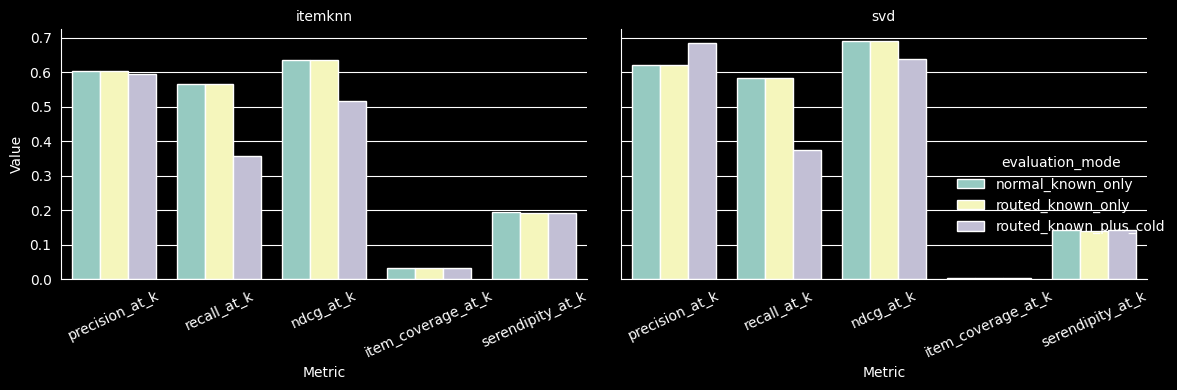

In [13]:
selected_metric_names = [
    "precision_at_k",
    "recall_at_k",
    "ndcg_at_k",
    "item_coverage_at_k",
    "serendipity_at_k",
]

plot_dataframe = comparison_dataframe.melt(
    id_vars=["model_name", "evaluation_mode"],
    value_vars=selected_metric_names,
    var_name="metric_name",
    value_name="metric_value",
)

g = sns.catplot(
    data=plot_dataframe,
    x="metric_name",
    y="metric_value",
    hue="evaluation_mode",
    col="model_name",
    kind="bar",
    height=4.0,
    aspect=1.2,
)
g.set_axis_labels("Metric", "Value")
g.set_titles("{col_name}")
for axis in g.axes.flat:
    axis.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## Delta Table (Routed Known - Normal Known)

Positive values mean the router mode improved the metric on the same known-user cohort.

In [14]:
known_mode_dataframe = comparison_dataframe[comparison_dataframe["evaluation_mode"].isin(["normal_known_only", "routed_known_only"])].copy()
known_mode_pivot = known_mode_dataframe.pivot(index="model_name", columns="evaluation_mode")

delta_rows = {}
for metric_name in [
    "rmse_value",
    "mae_value",
    "precision_at_k",
    "recall_at_k",
    "ndcg_at_k",
    "novelty_at_k",
    "diversity_at_k",
    "item_coverage_at_k",
    "intra_list_similarity_at_k",
    "item_to_history_distance_at_k",
    "serendipity_at_k",
]:
    routed_values = known_mode_pivot[(metric_name, "routed_known_only")]
    normal_values = known_mode_pivot[(metric_name, "normal_known_only")]
    delta_rows[metric_name] = routed_values - normal_values

delta_dataframe = pd.DataFrame(delta_rows)
delta_dataframe

,rmse_value,mae_value,precision_at_k,recall_at_k,ndcg_at_k,novelty_at_k,diversity_at_k,item_coverage_at_k,intra_list_similarity_at_k,item_to_history_distance_at_k,serendipity_at_k
model_name,,,,,,,,,,,
itemknn,0.0,0.0,0.0,0.0,0.0,-0.269592,-0.004955,-0.000115,0.004955,-0.003034,-0.003034
svd,0.0,0.0,0.0,0.0,0.0,-0.025499,-0.000159,0.000000,0.000159,-0.001008,-0.001008
